In [145]:
# Importing necessaries libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings
warnings.filterwarnings('ignore')

# preprocessing libraries
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix

# statistical libraries
from scipy import stats
from scipy.stats import zscore, skew

# set style for better visualisations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


In [146]:
data= 'cleaned_loan_dataset.csv'

In [147]:
df= pd.read_csv(data)

In [148]:
numerical_col=df.select_dtypes(include=[np.number]).columns
numerical_col

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'loan_paid_back'],
      dtype='object')

In [149]:
# create a copy for preprocessing 
data= df.copy()

numerical= data[numerical_col]

# 1. checking for missing values (EDA showed no missing values)
print("\n1.  Missing Values:")
missing_values = data.isnull().sum()
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("No missing values found (as expected from EDA)")

#2. check for duplicates
print("\n2. Duplicate Rows:")
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f'Percentage of duplicates: {(duplicates/len(data))* 100:.2sf}%')


# 3. Check skewness for variables identified in EDA as right-skewed
print("\n3. Skewness Analysis (EDA identified right-skewed variables):")    
skewed_vars = ['debt_to_income_ratio','loan_amount','interest_rate', 'credit_score','annual_income']
for var in skewed_vars:
    if var in data.columns:
        skewness = data[var].skew()
        print(f"{var}: skewness = {skewness:.3f} ({'right-skewed' if skewness > 0.5 else 'approximately normal'})")







1.  Missing Values:
No missing values found (as expected from EDA)

2. Duplicate Rows:
Number of duplicate rows: 0

3. Skewness Analysis (EDA identified right-skewed variables):
debt_to_income_ratio: skewness = 1.407 (right-skewed)
loan_amount: skewness = 0.207 (approximately normal)
interest_rate: skewness = 0.050 (approximately normal)
credit_score: skewness = -0.167 (approximately normal)
annual_income: skewness = 1.720 (right-skewed)


## Log-transform skewed variables as recommended by EDA

In [150]:
# Log-transform skewed variables as recommended by EDA
print("=== LOG-TRANSFORMING SKEWED VARIABLES ===")
print("EDA identified these variables as right-skewed and recommended log transformation:")

# Variables to log-transform based on EDA findings
skewed_vars = ['debt_to_income_ratio','loan_amount','interest_rate', 'credit_score','annual_income']

for var in skewed_vars:
    if var in data.columns:
        # Check if variable has zero or negative values
        min_val = data[var].min()
        if min_val <= 0:
            # Use log1p for variables with zeros
            data[f'{var}_log'] = np.log1p(data[var])
            print(f"✓ {var}: Applied log1p transformation (had {min_val:.3f} minimum value)")
        else:
            # Use log for positive values only
            data[f'{var}_log'] = np.log1p(data[var])
            print(f"✓ {var}: Applied log transformation")
        
        # Check skewness before and after
        original_skew = skew(data[var])
        transformed_skew = skew(data[f'{var}_log'])
        print(f"  Original skewness: {original_skew:.3f} → Transformed skewness: {transformed_skew:.3f}")

print(f"\nDataset shape after log transformation: {data.shape}")
print("New log-transformed columns:", [col for col in data.columns if '_log' in col])

=== LOG-TRANSFORMING SKEWED VARIABLES ===
EDA identified these variables as right-skewed and recommended log transformation:
✓ debt_to_income_ratio: Applied log transformation
  Original skewness: 1.407 → Transformed skewness: 1.219
✓ loan_amount: Applied log transformation
  Original skewness: 0.207 → Transformed skewness: -1.694
✓ interest_rate: Applied log transformation
  Original skewness: 0.050 → Transformed skewness: -0.452
✓ credit_score: Applied log transformation
  Original skewness: -0.167 → Transformed skewness: -0.427
✓ annual_income: Applied log transformation
  Original skewness: 1.720 → Transformed skewness: -0.342

Dataset shape after log transformation: (593994, 17)
New log-transformed columns: ['debt_to_income_ratio_log', 'loan_amount_log', 'interest_rate_log', 'credit_score_log', 'annual_income_log']


## Checking out for outliers found in EDA

In [151]:
numerical_col =df.select_dtypes(include=[np.number]).columns
numerical_col
for col in numerical_col:
    print(f'{col} = {df[col].skew():.3f}"  skewness value')




annual_income = 1.720"  skewness value
debt_to_income_ratio = 1.407"  skewness value
credit_score = -0.167"  skewness value
loan_amount = 0.207"  skewness value
interest_rate = 0.050"  skewness value
loan_paid_back = -1.491"  skewness value


In [152]:

# Outlier treatment based on EDA recommendations
print("=== OUTLIER TREATMENT (IQR-CAPPING METHOD) ===")

# Define numerical columns (excluding target)
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if 'Loan_Status' in numerical_cols:
    numerical_cols.remove('Loan_Status')

print(f"Treating outliers in {len(numerical_cols)} numerical features...")

# Apply IQR-capping method
outliers_capped = 0
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers before capping
    outliers_before = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()
    
    if outliers_before > 0:
        # Cap outliers
        data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
        data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])
        outliers_capped += outliers_before
        print(f"✓ {col}: Capped {outliers_before} outliers")

print(f"\nTotal outliers capped: {outliers_capped}")
print(f"Dataset shape after outlier treatment: {data.shape}")

=== OUTLIER TREATMENT (IQR-CAPPING METHOD) ===


Treating outliers in 11 numerical features...
✓ annual_income: Capped 15917 outliers
✓ debt_to_income_ratio: Capped 17556 outliers
✓ credit_score: Capped 5901 outliers
✓ loan_amount: Capped 2902 outliers
✓ interest_rate: Capped 5136 outliers
✓ loan_paid_back: Capped 119500 outliers
✓ debt_to_income_ratio_log: Capped 13412 outliers
✓ loan_amount_log: Capped 37392 outliers
✓ interest_rate_log: Capped 8014 outliers
✓ credit_score_log: Capped 7462 outliers
✓ annual_income_log: Capped 2979 outliers

Total outliers capped: 236171
Dataset shape after outlier treatment: (593994, 17)


## Feature Engineering

In [153]:
data.head(5)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,debt_to_income_ratio_log,loan_amount_log,interest_rate_log,credit_score_log,annual_income_log
0,29367.99,0.084,736.0,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.080658,8.327875,2.685805,6.602588,10.287695
1,22108.02,0.166,636.0,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,1.0,0.153579,8.432528,2.633327,6.456770,10.003741
2,49566.20,0.097,694.0,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,0.092579,9.741330,2.375836,6.543912,10.811085
3,46858.25,0.065,536.5,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,0.062975,8.451797,2.839078,6.311989,10.754904
4,25496.70,0.053,665.0,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.051643,9.407996,2.416806,6.501290,10.146344


In [154]:
categorical_col= df.select_dtypes(include="object").columns
categorical_col

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')

In [155]:
# encoding categorical variables
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le= LabelEncoder()
binary_col= ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
for col in binary_col:
    data[col] = le.fit_transform(data[col])
data.head()


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,debt_to_income_ratio_log,loan_amount_log,interest_rate_log,credit_score_log,annual_income_log
0,29367.99,0.084,736.0,2528.42,13.67,0,2,1,2,6,12,1.0,0.080658,8.327875,2.685805,6.602588,10.287695
1,22108.02,0.166,636.0,4593.10,12.92,1,1,2,0,2,17,1.0,0.153579,8.432528,2.633327,6.456770,10.003741
2,49566.20,0.097,694.0,17005.15,9.76,1,2,1,0,2,14,1.0,0.092579,9.741330,2.375836,6.543912,10.811085
3,46858.25,0.065,536.5,4682.48,16.10,0,2,1,0,2,25,1.0,0.062975,8.451797,2.839078,6.311989,10.754904
4,25496.70,0.053,665.0,12184.43,10.21,1,1,1,0,6,15,1.0,0.051643,9.407996,2.416806,6.501290,10.146344


## Scaled numeric data

In [156]:
numerical_col

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'loan_paid_back'],
      dtype='object')

In [157]:
# let normalise numeric values to help algorithms like Logistic or SVM perform better.


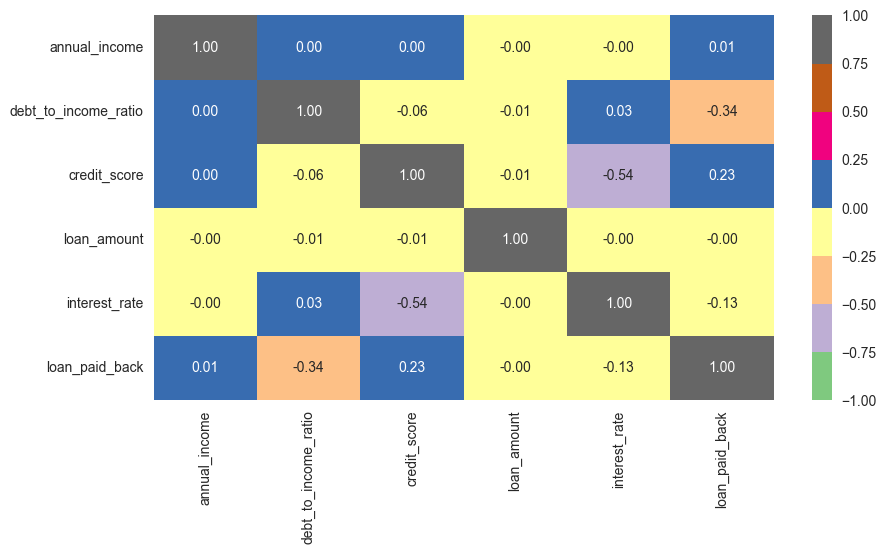

In [158]:
# 3. Examine the correlation of each feature with the target variable (quality)

cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Accent"
)
plt.show()

In [159]:
[numerical_col]

[Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
        'interest_rate', 'loan_paid_back'],
       dtype='object')]

In [160]:
# Feature selection based on EDA correlation evidence
print("=== FEATURE SELECTION BASED ON EDA CORRELATION EVIDENCE ===")

# Separate features and target
X = data.drop(columns=['loan_paid_back'])
y = data['loan_paid_back']



scaler= StandardScaler()
numerical_col_mod= numerical_col.drop('loan_paid_back')
X[numerical_col_mod]= scaler.fit_transform(X[numerical_col_mod])
X[numerical_col_mod].std()

print(f"Total features available: {X.shape[1]}")

# EDA-identified high-signal features (|correlation| > 0.2)
high_signal_features = [ 'prevailing_wage', 'require_job_traing', 'education_of_employee']
print(f"\nEDA-identified high-signal features: {high_signal_features}")

# EDA-identified low-signal features (|correlation| < 0.1) 
low_signal_features = ['has_job_expreriences', 'full_time_position']
print(f"EDA-identified low-signal features: {low_signal_features}")

# Check which features are actually available
available_high_signal = [f for f in high_signal_features if f in X.columns]
available_low_signal = [f for f in low_signal_features if f in X.columns]

print(f"\nAvailable high-signal features: {available_high_signal}")
print(f"Available low-signal features: {available_low_signal}")

# Create feature sets for evaluation
print("\n=== FEATURE SETS FOR EVALUATION ===")

# Set 1: All original features (excluding low-signal)
features_exclude_low_signal = [col for col in X.columns if col not in low_signal_features]
print(f"Set 1 - Exclude low-signal features: {len(features_exclude_low_signal)} features")

# Set 2: High-signal + engineered features
high_signal_plus_engineered = available_high_signal + [col for col in X.columns if any(keyword in col.lower() for keyword in ['ratio', 'interaction', 'balance', 'total', 'log'])]
print(f"Set 2 - High-signal + engineered: {len(high_signal_plus_engineered)} features")

# Set 3: All features (for comparison)
all_features = list(X.columns)
print(f"Set 3 - All features: {len(all_features)} features")

# Let's use Set 2 (high-signal + engineered) as recommended by EDA
selected_features = high_signal_plus_engineered
print(f"\n✓ Selected feature set: {len(selected_features)} features")
print("Selected features:", selected_features)


=== FEATURE SELECTION BASED ON EDA CORRELATION EVIDENCE ===
Total features available: 16

EDA-identified high-signal features: ['prevailing_wage', 'require_job_traing', 'education_of_employee']
EDA-identified low-signal features: ['has_job_expreriences', 'full_time_position']

Available high-signal features: []
Available low-signal features: []

=== FEATURE SETS FOR EVALUATION ===
Set 1 - Exclude low-signal features: 16 features
Set 2 - High-signal + engineered: 6 features
Set 3 - All features: 16 features

✓ Selected feature set: 6 features
Selected features: ['debt_to_income_ratio', 'debt_to_income_ratio_log', 'loan_amount_log', 'interest_rate_log', 'credit_score_log', 'annual_income_log']


In [ ]:
# Stratified data splitting based on EDA findings about class imbalance
print("=== STRATIFIED DATA SPLITTING ===")
print("EDA identified class imbalance - using stratified splitting to preserve class distribution")

# Select the chosen features
X_selected = X[selected_features]
print(f"Selected features shape: {X_selected.shape}")

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 75% train, 25% validation (of the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\nData split results:")
print(f"Training set: {X_train.shape} ({(X_train.shape[0]/len(X_selected))*100:.1f}%)")
print(f"Validation set: {X_val.shape} ({(X_val.shape[0]/len(X_selected))*100:.1f}%)")
print(f"Test set: {X_test.shape} ({(X_test.shape[0]/len(X_selected))*100:.1f}%)")

# Check class distribution in each set (should be similar due to stratification)
print(f"\nClass distribution verification:")
print("Training set quality distribution:")
print(y_train.value_counts().sort_index())
print("\nValidation set quality distribution:")
print(y_val.value_counts().sort_index())
print("\nTest set quality distribution:")
print(y_test.value_counts().sort_index())


=== STRATIFIED DATA SPLITTING ===
EDA identified class imbalance - using stratified splitting to preserve class distribution
Selected features shape: (593994, 6)

Data split results:
Training set: (356396, 6) (60.0%)
Validation set: (118799, 6) (20.0%)
Test set: (118799, 6) (20.0%)

Class distribution verification:
Training set quality distribution:
loan_paid_back
1.0    356396
Name: count, dtype: int64

Validation set quality distribution:
loan_paid_back
1.0    118799
Name: count, dtype: int64

Test set quality distribution:
loan_paid_back
1.0    118799
Name: count, dtype: int64


In [162]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Train baseline model
model = RandomForestClassifier(random_state=234)
model.fit(X_train, y_train)
# Predict
y_pred = model.predict(X_test)
# y_prob = model.predict_proba(X_test)[:, 1]
# y_pred = (y_prob > 0.3).astype(int)
y_pred = (y_pred > 0.3).astype(int)
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

         1.0       1.00      1.00      1.00    118799

    accuracy                           1.00    118799
   macro avg       1.00      1.00      1.00    118799
weighted avg       1.00      1.00      1.00    118799


Confusion Matrix:
 [[118799]]


In [ ]:
y_test


380582    1.0
199210    1.0
266577    1.0
270680    1.0
465448    1.0
         ... 
489897    1.0
456570    1.0
42159     1.0
277826    1.0
191026    1.0
Name: loan_paid_back, Length: 118799, dtype: float64

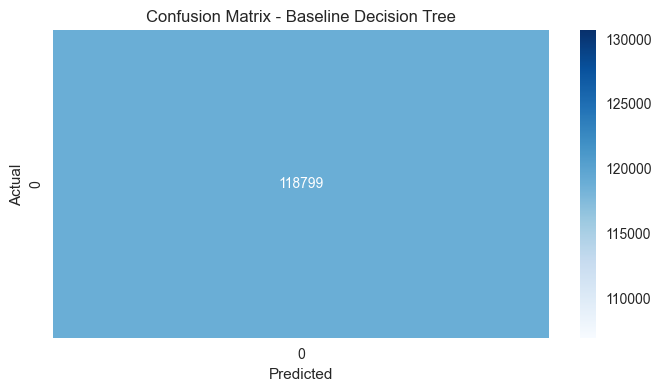

In [163]:

plt.figure(figsize=(8,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Baseline Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()